## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

## 2. Load Data

In [2]:
df = pd.read_csv('Country-data.csv')
print('Shape:', df.shape)
df.head()

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [4]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

## 3. Preprocessing

In [5]:
df.columns = df.columns.str.strip()
df.drop_duplicates(inplace=True)

for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

for col in df.columns:
    if col != 'country':
        df[col].fillna(df[col].median(), inplace=True)

print('Updated Shape:', df.shape)
print('Missing values remaining:', df.isnull().sum().sum())

Updated Shape: (167, 10)
Missing values remaining: 0


In [6]:
country_names = df['country']
X = df.drop('country', axis=1)
print('Features shape:', X.shape)
X.head()

Features shape: (167, 9)


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 4. EDA

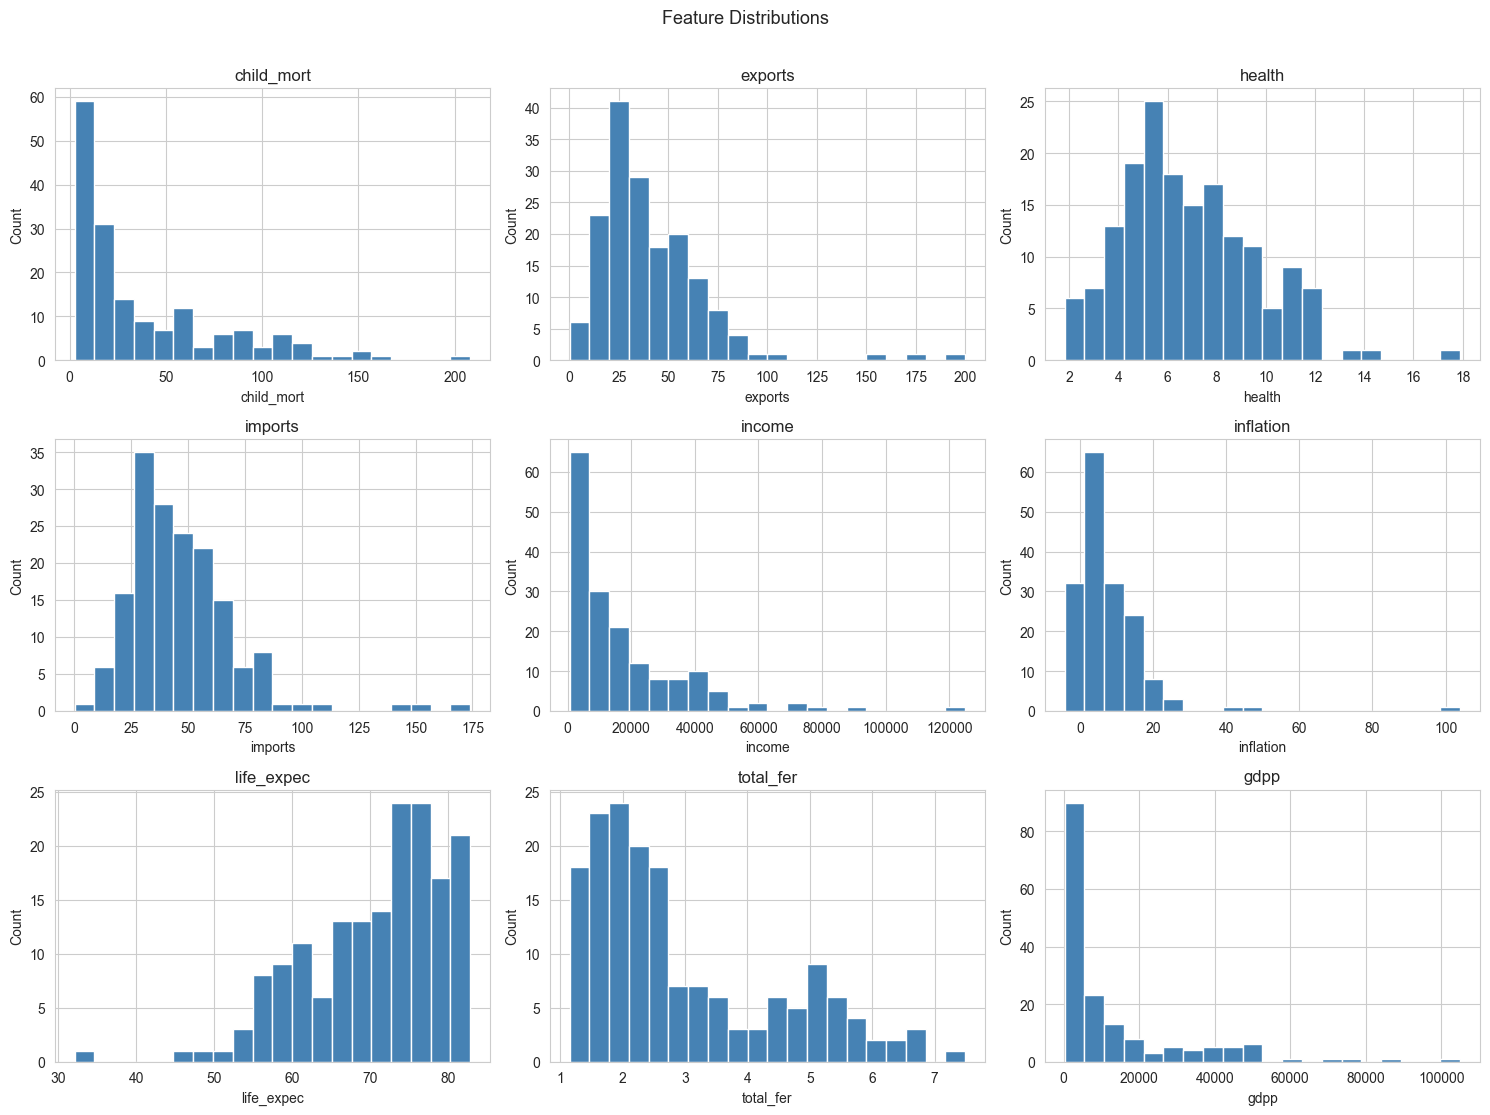

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()
for i, col in enumerate(X.columns):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
plt.suptitle('Feature Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

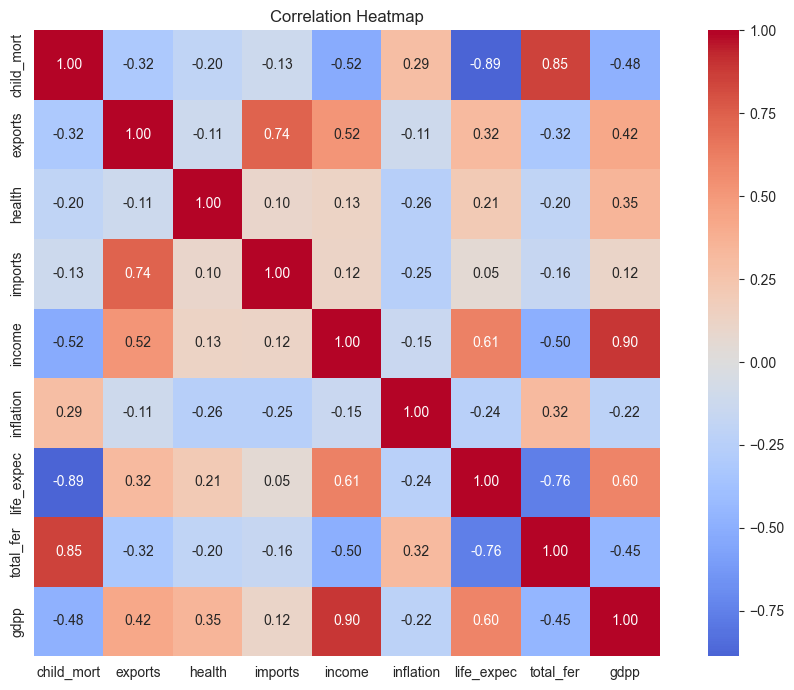

In [9]:
plt.figure(figsize=(10, 7))
sns.heatmap(X.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

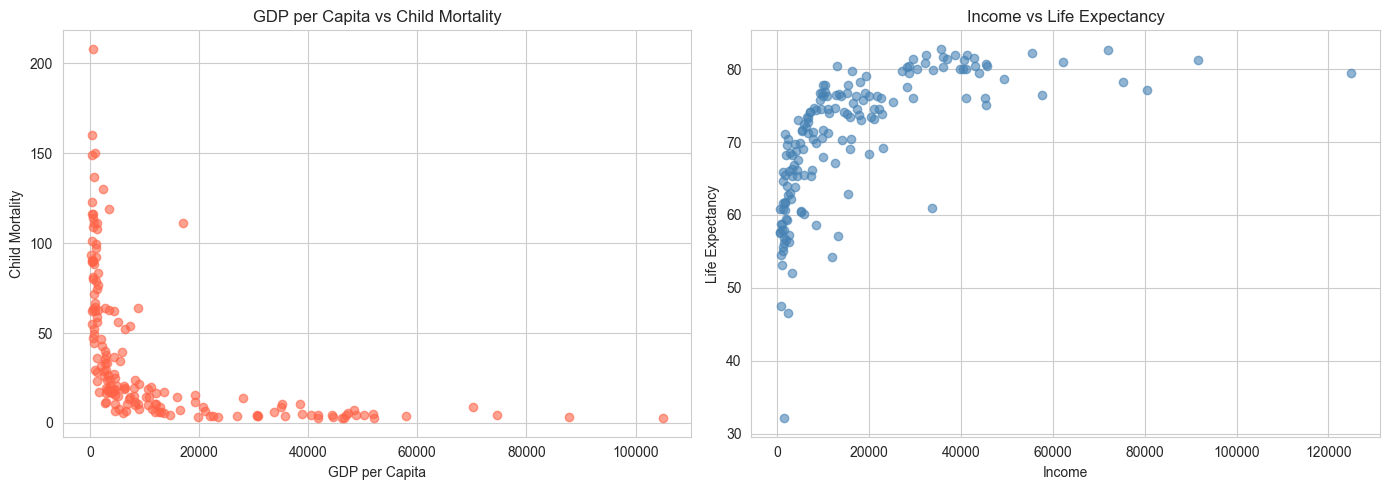

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['gdpp'], df['child_mort'], alpha=0.6, color='tomato')
axes[0].set_xlabel('GDP per Capita')
axes[0].set_ylabel('Child Mortality')
axes[0].set_title('GDP per Capita vs Child Mortality')

axes[1].scatter(df['income'], df['life_expec'], alpha=0.6, color='steelblue')
axes[1].set_xlabel('Income')
axes[1].set_ylabel('Life Expectancy')
axes[1].set_title('Income vs Life Expectancy')

plt.tight_layout()
plt.show()

## 5. K-Means Clustering
### 5.1 Elbow Method

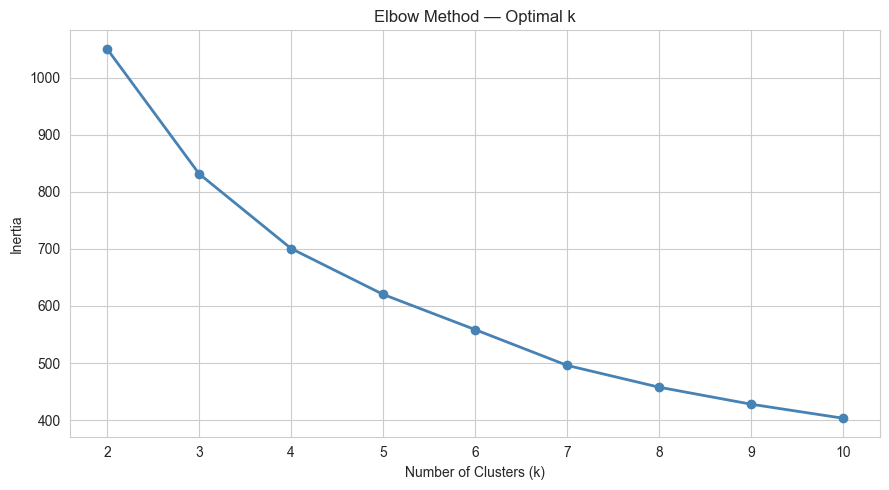

In [11]:
inertia = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(list(k_values), inertia, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method — Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(list(k_values))
plt.grid(True)
plt.tight_layout()
plt.show()

### 5.2 Fit K-Means (k=3)

In [12]:
best_k = 3
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
df['KMeans_Cluster'] = kmeans_labels

print('Cluster distribution:')
print(df['KMeans_Cluster'].value_counts())

Cluster distribution:
KMeans_Cluster
2    84
1    47
0    36
Name: count, dtype: int64


In [13]:
sil_score = silhouette_score(X_scaled, kmeans_labels)
print('Silhouette Score:', round(sil_score, 4))

Silhouette Score: 0.2833


In [14]:
cluster_summary = df.groupby('KMeans_Cluster').mean(numeric_only=True).round(2)
cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans_Cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


In [15]:
for cluster in sorted(df['KMeans_Cluster'].unique()):
    print(f'Cluster {cluster}:')
    display(df[df['KMeans_Cluster'] == cluster][['country']].head(8))
    print()

Cluster 0:


,country
7,Australia
8,Austria
11,Bahrain
15,Belgium
23,Brunei
29,Canada
42,Cyprus
43,Czech Republic



Cluster 1:


,country
0,Afghanistan
3,Angola
17,Benin
21,Botswana
25,Burkina Faso
26,Burundi
28,Cameroon
31,Central African Republic



Cluster 2:


,country
1,Albania
2,Algeria
4,Antigua and Barbuda
5,Argentina
6,Armenia
9,Azerbaijan
10,Bahamas
12,Bangladesh


## 6. DBSCAN Clustering

In [16]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
df['DBSCAN_Cluster'] = dbscan_labels

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise    = (dbscan_labels == -1).sum()

print(f'Clusters found : {n_clusters}')
print(f'Noise points   : {n_noise}')
print()
print(pd.Series(dbscan_labels).value_counts())

Clusters found : 1
Noise points   : 30

 0    137
-1     30
Name: count, dtype: int64


In [17]:
valid = dbscan_labels != -1
n_clusters_db = len(set(dbscan_labels[valid]))

if valid.sum() > 1 and n_clusters_db > 1:
    sil_db = silhouette_score(X_scaled[valid], dbscan_labels[valid])
    print(f'Silhouette Score (DBSCAN, non-noise): {round(sil_db, 4)}')
else:
    print(f'DBSCAN found only {n_clusters_db} cluster — silhouette score requires at least 2.')
    print('This is expected with eps=1.5, min_samples=5 on this dataset.')

DBSCAN found only 1 cluster — silhouette score requires at least 2.
This is expected with eps=1.5, min_samples=5 on this dataset.


## 7. PCA Visualization

In [18]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f'Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%')

Variance explained: 63.1%


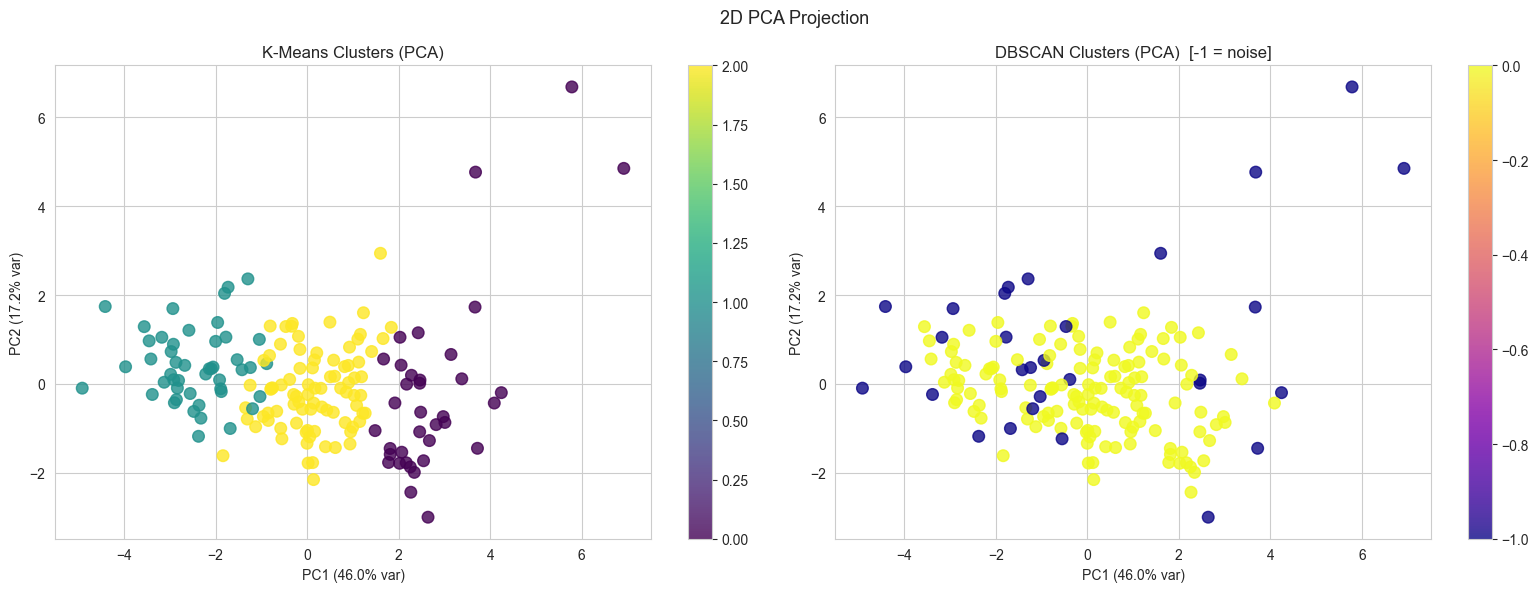

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                           c=kmeans_labels, cmap='viridis', s=70, alpha=0.8)
axes[0].set_title('K-Means Clusters (PCA)')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.colorbar(scatter1, ax=axes[0])

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                           c=dbscan_labels, cmap='plasma', s=70, alpha=0.8)
axes[1].set_title('DBSCAN Clusters (PCA)  [-1 = noise]')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.colorbar(scatter2, ax=axes[1])

plt.suptitle('2D PCA Projection', fontsize=13)
plt.tight_layout()
plt.show()

In [20]:
print('''
1. Countries in Cluster 0 have extremely high child mortality and low GDP — these are low-development nations that need the most aid.
2. Cluster 2 groups high-income, high GDP countries with the best life expectancy and lowest child mortality — these are the top-tier economic zones.
3. Cluster 1 sits in the middle — moderate income and decent life expectancy, mostly emerging economies still developing.
4. DBSCAN marks a few extreme outliers as noise (like very high GDP countries) — they don't fit neatly into any cluster.
5. GDP per capita and child mortality are the two biggest factors separating countries — wealthier nations almost always have better health outcomes.
''')


1. Countries in Cluster 0 have extremely high child mortality and low GDP — these are low-development nations that need the most aid.
2. Cluster 2 groups high-income, high GDP countries with the best life expectancy and lowest child mortality — these are the top-tier economic zones.
3. Cluster 1 sits in the middle — moderate income and decent life expectancy, mostly emerging economies still developing.
4. DBSCAN marks a few extreme outliers as noise (like very high GDP countries) — they don't fit neatly into any cluster.
5. GDP per capita and child mortality are the two biggest factors separating countries — wealthier nations almost always have better health outcomes.

